In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AutoTec") \
    .config("spark.mongodb.read.connection.uri", "mongodb://mongodb:27017/proyecto_bigdata.datos_scraping") \
    .getOrCreate()

print("Spark iniciado")

Spark iniciado


In [2]:
df = spark.read.format("mongodb").load()

df.show(5)

+--------------------+----+----------+-----------+-------------------+-------------+-------+-----------+-------+--------------------+-------+--------------------+-------+
|                 _id| año|    ciudad|combustible|      fecha_captura|       fuente|  grupo|kilometraje|  marca|              modelo| precio|                 url|usuario|
+--------------------+----+----------+-----------+-------------------+-------------+-------+-----------+-------+--------------------+-------+--------------------+-------+
|69eed3d14fc93b54d...|2025|  Santiago|       NULL|2026-04-27 03:09:49|autos.cari.cl|AutoTec|       NULL|Hyundai|TUCSON 2.0 NX4 PL...|2.149E7|https://autos.car...|jocelyn|
|69eed3d14fc93b54d...|2026|  Santiago|       NULL|2026-04-27 03:09:52|autos.cari.cl|AutoTec|       NULL|Hyundai|GRAND I10 1.2 PLU...|1.029E7|https://autos.car...|jocelyn|
|69eed3d14fc93b54d...|2024|Concepción|       NULL|2026-04-27 03:09:52|autos.cari.cl|AutoTec|       NULL|Hyundai|CRETA 1.5 PLUS SU...|1.589E7|http

In [3]:
df.printSchema()

root
 |-- _id: string (nullable = true)
 |-- año: integer (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- fuente: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: integer (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- url: string (nullable = true)
 |-- usuario: string (nullable = true)



In [5]:
df = df.dropna(subset=["precio", "marca"])

df.printSchema()

root
 |-- _id: string (nullable = true)
 |-- año: integer (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- fuente: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: integer (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- url: string (nullable = true)
 |-- usuario: string (nullable = true)



In [6]:
df.groupBy("marca") \
  .avg("precio") \
  .orderBy("avg(precio)", ascending=False) \
  .show()

+---------+--------------------+
|    marca|         avg(precio)|
+---------+--------------------+
|    Mazda|             2.493E7|
|   Toyota|2.0417272727272727E7|
|Chevrolet|            1.6125E7|
|  Hyundai|1.6101111111111112E7|
|   Nissan|1.4537368421052631E7|
|   Suzuki|1.0923333333333334E7|
|      Kia|           1.08275E7|
|    Vendo|           2100000.0|
+---------+--------------------+



In [7]:
df.groupBy("marca") \
  .count() \
  .orderBy("count", ascending=False) \
  .show()

+---------+-----+
|    marca|count|
+---------+-----+
|Chevrolet|   20|
|    Mazda|   20|
|   Nissan|   19|
|  Hyundai|   18|
|   Toyota|   11|
|      Kia|    8|
|   Suzuki|    3|
|    Vendo|    1|
+---------+-----+



In [8]:
df.selectExpr("avg(kilometraje) as km_promedio").show()

+-----------+
|km_promedio|
+-----------+
|     2001.0|
+-----------+



In [9]:
df.groupBy("combustible") \
  .count() \
  .show()

+-----------+-----+
|combustible|count|
+-----------+-----+
|       NULL|   97|
|     Diesel|    3|
+-----------+-----+



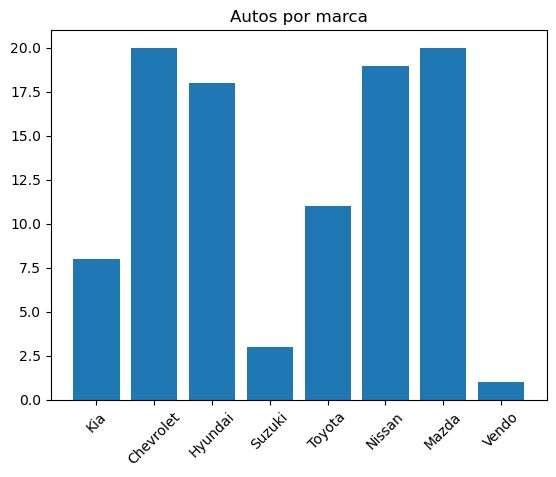

In [10]:
pdf = df.groupBy("marca").count().toPandas()

import matplotlib.pyplot as plt

plt.bar(pdf["marca"], pdf["count"])
plt.xticks(rotation=45)
plt.title("Autos por marca")
plt.show()